# Multimodal CT + EHR-Derived Clinical Risk Prediction in NSCLC

## AMS 563 Project

**Dataset:** NSCLC-Radiogenomics (TCIA)  
**Modalities:** Chest CT + EHR-derived structured clinical variables  
**Prediction target:** `Survival Status` (`Dead` = 1, `Alive` = 0)  
**Goal:** Compare clinical-only, CT-only, and multimodal fusion models.

### Practical project plan
- Run a strong clinical baseline on the full labeled table
- Run CT-only and fusion models on a **matched subset** of patients with downloaded DICOM studies
- Keep the image pipeline lightweight so the notebook can run in Colab


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install in Colab if needed
!pip install -q pandas numpy matplotlib seaborn scikit-learn pydicom torch torchvision tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 33.7 MB/s eta 0:00:00


In [3]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix

import pydicom

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## 1. Paths

### Local Mac paths
These match your current laptop layout.

### Colab usage later
When you move this to Drive, only update `PROJECT_ROOT`, `CLINICAL_FILE`, and `IMAGE_ROOT` in this cell.


In [4]:
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/AMS 563/project')
DATA_ROOT = PROJECT_ROOT / 'NLCSC-Radiogenomics'

CLINICAL_FILE = PROJECT_ROOT / 'NSCLCR01Radiogenomic_DATA_LABELS_2018-05-22_1500-shifted.csv'
IMAGE_ROOT = DATA_ROOT

CFG = {
    'random_state': 42,
    'max_patients_for_ct': 24,
    'img_size': 160,
    'n_slices': 12,
    'batch_size': 4,
    'num_workers': 2,
    'epochs': 6,
    'lr': 1e-3,
}

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CLINICAL_FILE exists:', CLINICAL_FILE.exists())
print('IMAGE_ROOT exists:', IMAGE_ROOT.exists())

PROJECT_ROOT: /content/drive/MyDrive/AMS 563/project
CLINICAL_FILE exists: True
IMAGE_ROOT exists: True


In [5]:
def list_some_files(root, max_items=30):
    root = Path(root)
    if not root.exists():
        print(f'Missing: {root}')
        return
    files = [p for p in root.rglob('*') if p.is_file()]
    print(f'Found {len(files)} files under {root}')
    for p in files[:max_items]:
        print(p.relative_to(root))

list_some_files(DATA_ROOT)


Found 28011 files under /content/drive/MyDrive/AMS 563/project/NLCSC-Radiogenomics
AMC-002/1.3.6.1.4.1.14519.5.2.1.4334.1501.318107938099351952423306401630/1.3.6.1.4.1.14519.5.2.1.4334.1501.426581693091941145906372008618/18d8b68b-b35d-4f27-ac2e-f2de7ebf05f6.dcm
AMC-002/1.3.6.1.4.1.14519.5.2.1.4334.1501.318107938099351952423306401630/1.3.6.1.4.1.14519.5.2.1.4334.1501.426581693091941145906372008618/1c77ebc4-301a-40d0-9cf8-511218775690.dcm
AMC-002/1.3.6.1.4.1.14519.5.2.1.4334.1501.318107938099351952423306401630/1.3.6.1.4.1.14519.5.2.1.4334.1501.426581693091941145906372008618/1a72f244-f859-4ef4-85bd-307fb7352208.dcm
AMC-002/1.3.6.1.4.1.14519.5.2.1.4334.1501.318107938099351952423306401630/1.3.6.1.4.1.14519.5.2.1.4334.1501.426581693091941145906372008618/10b25eb1-bfb6-4290-84ac-a33b31cf6345.dcm
AMC-002/1.3.6.1.4.1.14519.5.2.1.4334.1501.318107938099351952423306401630/1.3.6.1.4.1.14519.5.2.1.4334.1501.426581693091941145906372008618/112962df-2112-468f-a1a1-4ce12034245b.dcm
AMC-002/1.3.6.1.4.1.14

## 2. Load Clinical Table and Create Label

In [6]:
clinical_df = pd.read_csv(CLINICAL_FILE)
print(clinical_df.shape)
display(clinical_df.head())
print(clinical_df.columns.tolist())


(211, 40)


,Case ID,Patient affiliation,Age at Histological Diagnosis,Weight (lbs),Gender,Ethnicity,Smoking status,Pack Years,Quit Smoking Year,%GG,...,Recurrence,Recurrence Location,Date of Recurrence,Date of Last Known Alive,Survival Status,Date of Death,Time to Death (days),CT Date,Days between CT and surgery,PET Date
0,AMC-001,Stanford,34,Not Collected,Male,Not Recorded In Database,Nonsmoker,NaN,NaN,Not Assessed,...,yes,distant,10/7/1994,1/7/1997,Dead,1/7/1997,872.0,8/10/1994,9,Not Collected
1,AMC-002,Stanford,33,Not Collected,Female,Not Recorded In Database,Nonsmoker,NaN,NaN,Not Assessed,...,no,NaN,NaN,3/20/1992,Alive,NaN,NaN,2/19/1992,3,Not Collected
2,AMC-003,Stanford,69,Not Collected,Female,Not Recorded In Database,Nonsmoker,NaN,NaN,Not Assessed,...,no,NaN,NaN,6/19/1996,Alive,NaN,NaN,2/23/1995,28,Not Collected
3,AMC-004,Stanford,80,Not Collected,Female,Not Recorded In Database,Nonsmoker,NaN,NaN,Not Assessed,...,no,NaN,NaN,12/13/1996,Alive,NaN,NaN,12/26/1992,47,Not Collected
4,AMC-005,Stanford,76,Not Collected,Male,Not Recorded In Database,Former,30,1962.0,Not Assessed,...,yes,distant,1/4/1996,1/7/1997,Alive,NaN,NaN,7/21/1994,2,Not Collected


['Case ID', 'Patient affiliation', 'Age at Histological Diagnosis', 'Weight (lbs)', 'Gender', 'Ethnicity', 'Smoking status', 'Pack Years', 'Quit Smoking Year', '%GG', 'Tumor Location (choice=RUL)', 'Tumor Location (choice=RML)', 'Tumor Location (choice=RLL)', 'Tumor Location (choice=LUL)', 'Tumor Location (choice=LLL)', 'Tumor Location (choice=L Lingula)', 'Tumor Location (choice=Unknown)', 'Histology ', 'Pathological T stage', 'Pathological N stage', 'Pathological M stage', 'Histopathological Grade', 'Lymphovascular invasion', 'Pleural invasion (elastic, visceral, or parietal)', 'EGFR mutation status', 'KRAS mutation status', 'ALK translocation status', 'Adjuvant Treatment', 'Chemotherapy', 'Radiation', 'Recurrence', 'Recurrence Location', 'Date of Recurrence', 'Date of Last Known Alive', 'Survival Status', 'Date of Death', 'Time to Death (days)', 'CT Date', 'Days between CT and surgery', 'PET Date']


In [7]:
PATIENT_ID_COL = 'Case ID'
TARGET_COL = 'Survival Status'

def build_model_df(df):
    out = df.copy()
    out = out[out[PATIENT_ID_COL].notna()].copy()
    out = out[out[TARGET_COL].isin(['Alive', 'Dead'])].copy()
    out['label'] = (out[TARGET_COL] == 'Dead').astype(int)
    return out

model_df = build_model_df(clinical_df)
print(model_df[[PATIENT_ID_COL, TARGET_COL, 'label']].head())
print('\nLabel counts:')
print(model_df['label'].value_counts())


   Case ID Survival Status  label
0  AMC-001            Dead      1
1  AMC-002           Alive      0
2  AMC-003           Alive      0
3  AMC-004           Alive      0
4  AMC-005           Alive      0

Label counts:
label
0    148
1     63
Name: count, dtype: int64


## 3. Clinical-Only Baseline (Fastest Win)

This baseline uses the clinical CSV as your EHR-derived tabular modality.


In [8]:
DROP_NON_FEATURE = {
    'label',
    PATIENT_ID_COL,
    TARGET_COL,
    'Date of Recurrence',
    'Date of Last Known Alive',
    'Date of Death',
    'CT Date',
    'PET Date',
}

def prepare_tabular(df, feature_columns=None, fit=False, imputer=None, scaler=None):
    X_df = df.drop(columns=[c for c in DROP_NON_FEATURE if c in df.columns]).copy()
    X_df = pd.get_dummies(X_df, dummy_na=True)

    if fit:
        feature_columns = X_df.columns.tolist()
    else:
        X_df = X_df.reindex(columns=feature_columns, fill_value=0)

    if fit:
        imputer = SimpleImputer(strategy='most_frequent')
        scaler = StandardScaler()
        X = scaler.fit_transform(imputer.fit_transform(X_df))
    else:
        X = scaler.transform(imputer.transform(X_df))

    return X, feature_columns, imputer, scaler

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'auroc': roc_auc_score(y_true, y_prob),
        'auprc': average_precision_score(y_true, y_prob),
        'brier': brier_score_loss(y_true, y_prob),
        'sensitivity': tp / (tp + fn + 1e-8),
        'specificity': tn / (tn + fp + 1e-8),
    }

tab_train_df, tab_test_df = train_test_split(
    model_df, test_size=0.2, random_state=CFG['random_state'], stratify=model_df['label']
)

X_train_tab, feature_columns, tab_imputer, tab_scaler = prepare_tabular(tab_train_df, fit=True)
X_test_tab, _, _, _ = prepare_tabular(tab_test_df, feature_columns, fit=False, imputer=tab_imputer, scaler=tab_scaler)
y_train_tab = tab_train_df['label'].values
y_test_tab = tab_test_df['label'].values

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train_tab, y_train_tab)
tab_prob = lr_clf.predict_proba(X_test_tab)[:, 1]
print('Clinical baseline metrics:')
print(compute_metrics(y_test_tab, tab_prob))


Clinical baseline metrics:
{'auroc': np.float64(0.7589743589743589), 'auprc': np.float64(0.7595427170955951), 'brier': np.float64(0.14590112689890392), 'sensitivity': np.float64(0.6923076917751478), 'specificity': np.float64(0.8999999997)}


## 4. Match Patients to CT Studies

We will use only patients who have both a clinical row and at least one DICOM series.


In [9]:
def patient_image_dir(patient_id, image_root=IMAGE_ROOT):
    p = Path(image_root) / str(patient_id)
    return p if p.exists() else None

def count_dicoms(patient_id, image_root=IMAGE_ROOT):
    p = patient_image_dir(patient_id, image_root)
    if p is None:
        return 0
    return len(list(p.rglob('*.dcm')))

model_df['n_dicoms'] = model_df[PATIENT_ID_COL].apply(count_dicoms)
matched_df = model_df[model_df['n_dicoms'] > 0].copy()

print('Total labeled patients:', len(model_df))
print('Matched patients with DICOMs:', len(matched_df))
display(matched_df[[PATIENT_ID_COL, 'label', 'n_dicoms']].head())


Total labeled patients: 211
Matched patients with DICOMs: 24


,Case ID,label,n_dicoms
0,AMC-001,1,1171
1,AMC-002,0,421
2,AMC-003,0,1705
3,AMC-004,0,1106
4,AMC-005,0,895


In [10]:
subset_n = min(CFG['max_patients_for_ct'], len(matched_df))
subset_df = matched_df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), max(1, subset_n // 2)), random_state=CFG['random_state'])
).reset_index(drop=True)

if len(subset_df) > subset_n:
    subset_df = subset_df.sample(subset_n, random_state=CFG['random_state']).reset_index(drop=True)

print('Subset size used for CT/fusion:', len(subset_df))
print(subset_df['label'].value_counts())


Subset size used for CT/fusion: 24
label
0    12
1    12
Name: count, dtype: int64


/tmp/ipykernel_1116/1567249205.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subset_df = matched_df.groupby('label', group_keys=False).apply(


## 5. DICOM Loading Helpers

We pick the series with the most DICOM slices for each patient, sample a fixed number of slices, resize them, and normalize them.


In [11]:
def get_patient_series_dirs(patient_id):
    p = patient_image_dir(patient_id)
    if p is None:
        return []
    return [d for d in p.rglob('*') if d.is_dir() and len(list(d.glob('*.dcm'))) > 0]

def choose_main_series(patient_id):
    series_dirs = get_patient_series_dirs(patient_id)
    if not series_dirs:
        return None
    return max(series_dirs, key=lambda d: len(list(d.glob('*.dcm'))))

def load_dicom_series(series_dir):
    dcm_files = list(Path(series_dir).glob('*.dcm'))
    slices = []
    for fp in dcm_files:
        ds = pydicom.dcmread(str(fp), force=True)
        if not hasattr(ds, 'pixel_array'):
            continue
        arr = ds.pixel_array.astype(np.float32)
        slope = float(getattr(ds, 'RescaleSlope', 1.0))
        intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
        arr = arr * slope + intercept
        z = float(getattr(ds, 'InstanceNumber', len(slices)))
        slices.append((z, arr))
    if not slices:
        return None
    slices = [x[1] for x in sorted(slices, key=lambda x: x[0])]
    return np.stack(slices)

def preprocess_volume(volume, n_slices=12, img_size=160, hu_min=-1000, hu_max=400):
    idxs = np.linspace(0, len(volume) - 1, n_slices, dtype=int)
    sampled = volume[idxs]
    sampled = np.clip(sampled, hu_min, hu_max)
    sampled = (sampled - hu_min) / (hu_max - hu_min)
    sampled = torch.tensor(sampled).unsqueeze(1).float()
    sampled = F.interpolate(sampled, size=(img_size, img_size), mode='bilinear', align_corners=False)
    return sampled.squeeze(1).numpy().astype(np.float32)

example_pid = subset_df[PATIENT_ID_COL].iloc[0]
example_series = choose_main_series(example_pid)
print('Example patient:', example_pid)
print('Chosen series:', example_series)


Example patient: AMC-013
Chosen series: /content/drive/MyDrive/AMS 563/project/NLCSC-Radiogenomics/AMC-013/1.3.6.1.4.1.14519.5.2.1.4334.1501.283491629659084872767313598254/1.3.6.1.4.1.14519.5.2.1.4334.1501.234206494695321248318318754359


Raw volume shape: (268, 512, 512)
Processed shape: (12, 160, 160)


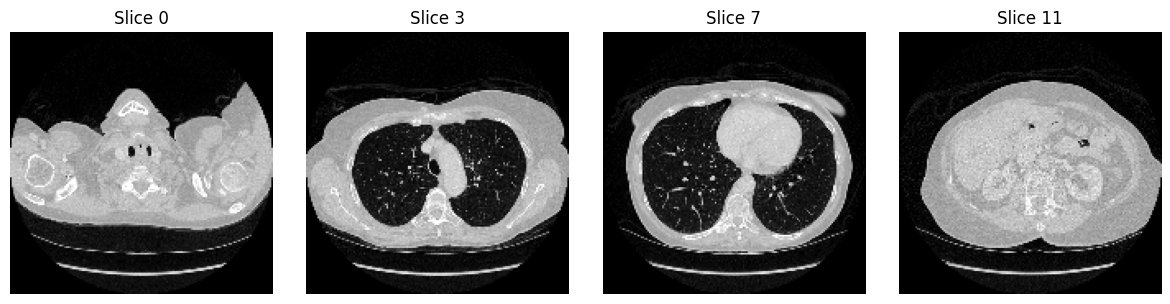

In [12]:
if example_series is not None:
    vol = load_dicom_series(example_series)
    proc = preprocess_volume(vol, CFG['n_slices'], CFG['img_size'])
    print('Raw volume shape:', vol.shape)
    print('Processed shape:', proc.shape)
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for ax, idx in zip(axes, np.linspace(0, CFG['n_slices'] - 1, 4, dtype=int)):
        ax.imshow(proc[idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Slice {idx}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 6. Build Matched Train/Test Split

In [13]:
ct_train_df, ct_test_df = train_test_split(
    subset_df, test_size=0.25, random_state=CFG['random_state'], stratify=subset_df['label']
)

X_train_ct_tab, ct_feature_columns, ct_imputer, ct_scaler = prepare_tabular(ct_train_df, fit=True)
X_test_ct_tab, _, _, _ = prepare_tabular(ct_test_df, ct_feature_columns, fit=False, imputer=ct_imputer, scaler=ct_scaler)

print('CT/Fusion train size:', len(ct_train_df))
print('CT/Fusion test size:', len(ct_test_df))


CT/Fusion train size: 18
CT/Fusion test size: 6


## 7. PyTorch Dataset

In [14]:
class NSCLCDataset(Dataset):
    def __init__(self, df, tabular_array, cfg):
        self.df = df.reset_index(drop=True)
        self.tab = tabular_array.astype(np.float32)
        self.cfg = cfg

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pid = row[PATIENT_ID_COL]
        series_dir = choose_main_series(pid)
        if series_dir is None:
            vol = np.zeros((self.cfg['n_slices'], self.cfg['img_size'], self.cfg['img_size']), dtype=np.float32)
        else:
            vol_raw = load_dicom_series(series_dir)
            vol = preprocess_volume(vol_raw, self.cfg['n_slices'], self.cfg['img_size'])

        ct = torch.tensor(vol).unsqueeze(1).repeat(1, 3, 1, 1).float()
        tab = torch.tensor(self.tab[idx]).float()
        y = torch.tensor(float(row['label'])).float()
        return ct, tab, y


## 8. Lightweight Models

In [15]:
class CTOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, ct, tab=None):
        b, n, c, h, w = ct.shape
        x = ct.view(b * n, c, h, w)
        x = self.conv(x).view(b, n, 64)
        x = x.mean(dim=1)
        return self.fc(x).squeeze(-1)

class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, ct, tab):
        return self.net(tab).squeeze(-1)

class FusionModel(nn.Module):
    def __init__(self, tab_dim):
        super().__init__()
        self.ct_encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.tab_encoder = nn.Sequential(
            nn.Linear(tab_dim, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 64)
        )
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, ct, tab):
        b, n, c, h, w = ct.shape
        x = ct.view(b * n, c, h, w)
        x = self.ct_encoder(x).view(b, n, 64)
        x = x.mean(dim=1)
        t = self.tab_encoder(tab)
        fused = torch.cat([x, t], dim=1)
        return self.head(fused).squeeze(-1)

print('Models ready.')


Models ready.


## 9. Training Utilities

In [16]:
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    all_y, all_p, losses = [], [], []
    criterion = nn.BCEWithLogitsLoss()

    for ct, tab, y in loader:
        ct, tab, y = ct.to(device), tab.to(device), y.to(device)
        with torch.set_grad_enabled(train_mode):
            logits = model(ct, tab)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_p.extend(probs)
        all_y.extend(y.detach().cpu().numpy())
        losses.append(loss.item())

    return np.mean(losses), compute_metrics(np.array(all_y), np.array(all_p))

def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3, name='model'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        tr_loss, tr_metrics = run_epoch(model, train_loader, optimizer)
        te_loss, te_metrics = run_epoch(model, test_loader, optimizer=None)
        history.append((tr_loss, te_loss, tr_metrics, te_metrics))
        print(f"{name} | epoch {epoch:02d} | train auc={tr_metrics['auroc']:.3f} | test auc={te_metrics['auroc']:.3f}")
    return model, history


## 10. Train CT-Only and Fusion Models on the Matched Subset

In [17]:
train_ds = NSCLCDataset(ct_train_df, X_train_ct_tab, CFG)
test_ds = NSCLCDataset(ct_test_df, X_test_ct_tab, CFG)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, num_workers=CFG['num_workers'])
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'])

print('Train batches:', len(train_loader))
print('Test batches:', len(test_loader))


Train batches: 5
Test batches: 2


In [18]:
tab_mlp = TabularMLP(X_train_ct_tab.shape[1])
tab_mlp, tab_hist = train_model(tab_mlp, train_loader, test_loader, epochs=CFG['epochs'], lr=CFG['lr'], name='tab_mlp')

ct_model = CTOnlyModel()
ct_model, ct_hist = train_model(ct_model, train_loader, test_loader, epochs=CFG['epochs'], lr=CFG['lr'], name='ct_only')

fusion_model = FusionModel(X_train_ct_tab.shape[1])
fusion_model, fusion_hist = train_model(fusion_model, train_loader, test_loader, epochs=CFG['epochs'], lr=CFG['lr'], name='fusion')


tab_mlp | epoch 01 | train auc=0.654 | test auc=0.778
tab_mlp | epoch 02 | train auc=0.963 | test auc=0.778
tab_mlp | epoch 03 | train auc=0.988 | test auc=0.778
tab_mlp | epoch 04 | train auc=1.000 | test auc=0.778
tab_mlp | epoch 05 | train auc=1.000 | test auc=0.778
tab_mlp | epoch 06 | train auc=1.000 | test auc=0.778
ct_only | epoch 01 | train auc=0.173 | test auc=0.778
ct_only | epoch 02 | train auc=0.704 | test auc=0.778
ct_only | epoch 03 | train auc=0.531 | test auc=0.333
ct_only | epoch 04 | train auc=0.667 | test auc=0.222
ct_only | epoch 05 | train auc=0.519 | test auc=0.222
ct_only | epoch 06 | train auc=0.654 | test auc=0.222
fusion | epoch 01 | train auc=0.481 | test auc=0.667
fusion | epoch 02 | train auc=0.988 | test auc=0.778
fusion | epoch 03 | train auc=0.988 | test auc=0.778
fusion | epoch 04 | train auc=1.000 | test auc=0.778
fusion | epoch 05 | train auc=1.000 | test auc=0.778
fusion | epoch 06 | train auc=1.000 | test auc=0.778


## 11. Final Notes for the PPT

- `Clinical/EHR-derived variables` come from the structured clinical CSV
- `CT-only` and `fusion` experiments are intentionally run on a matched subset for compute feasibility
- This is acceptable for a class project as long as you say it clearly
